In [1]:
!pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.6/979.6 kB 16.6 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import time
from sklearn.model_selection import KFold
from pykrige.ok3d import OrdinaryKriging3D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.spatial import ConvexHull, Delaunay
from math import sqrt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

seeg_path = '/content/drive/MyDrive/data/seeg'

Mounted at /content/drive


# Delta Band CV Metrics
   Method      MSE      MAE     RMSE       R2        R
  ExpKrig 0.002885 0.042262 0.053663 0.391497 0.636339
   Linear 0.003153 0.043119 0.056073 0.334054 0.614055
      KNN 0.003060 0.043603 0.055257 0.354201 0.611119
ExpInterp 0.004297 0.049746 0.065455 0.089177 0.544246
Chebyshev 0.003864 0.050452 0.062131 0.190008 0.442331
  BSpline 0.000822 0.020187 0.028643 0.827270 0.919203
      MLP 0.003870 0.049293 0.062184 0.187968 0.472939

# Delta Band Timing
   Method  CV_Avg(s)  CV_Tot(s)  Final(s)
  ExpKrig  63.168588 631.685879 95.328913
   Linear   0.081748   0.817477  0.089163
      KNN   0.002116   0.021163  0.039042
ExpInterp   0.012177   0.121772  0.698167
Chebyshev   0.002461   0.024606  0.007852
  BSpline   0.005475   0.054750  0.015166
      MLP   0.001782   0.017822  0.017479


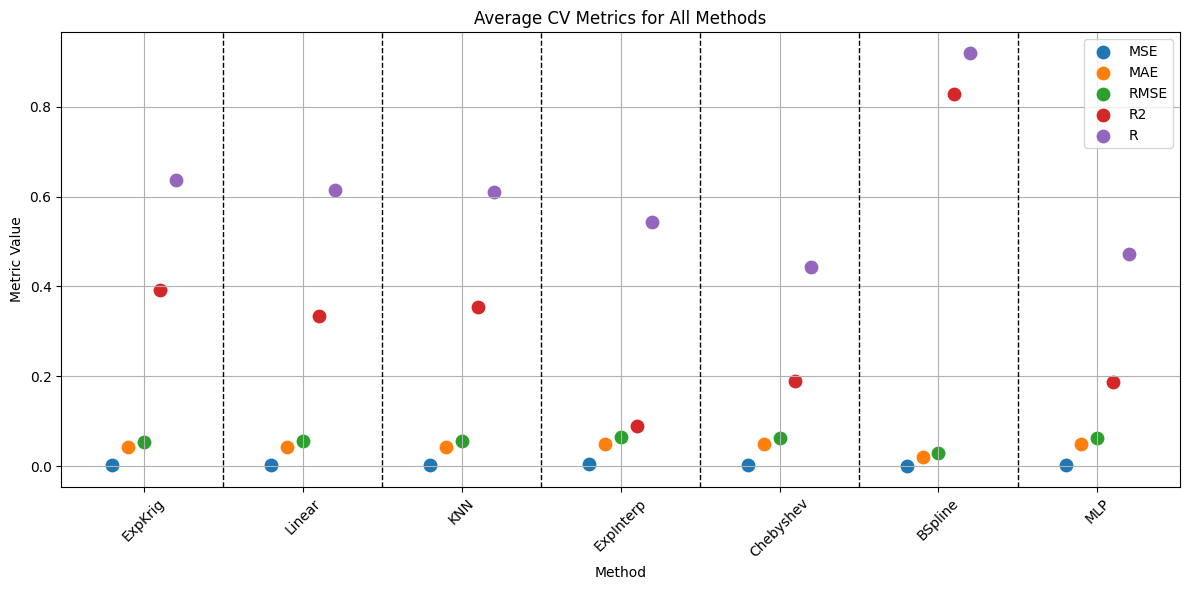

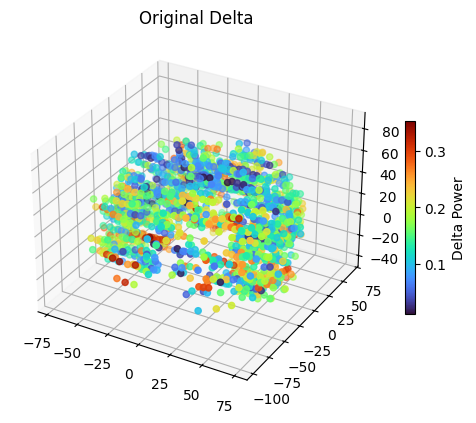

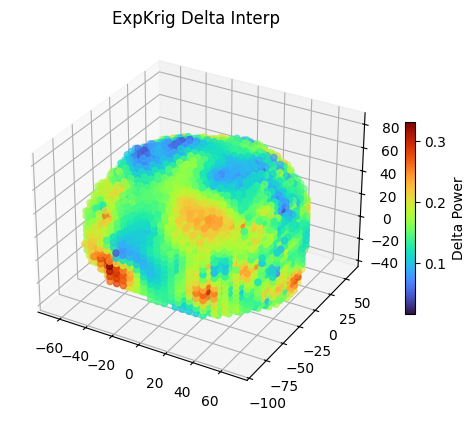

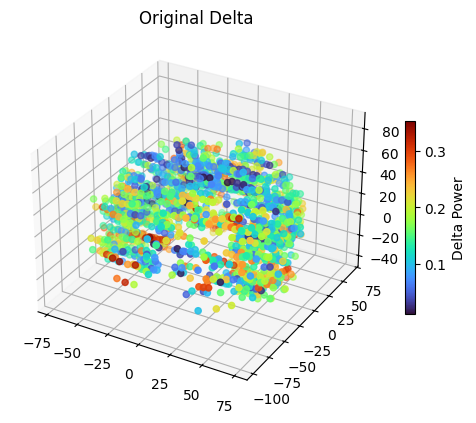

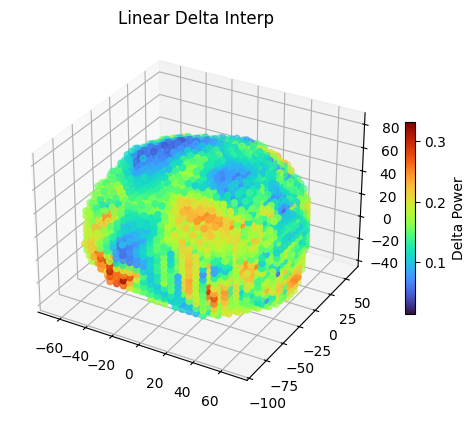

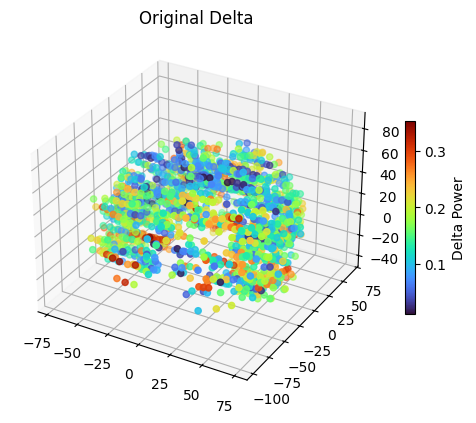

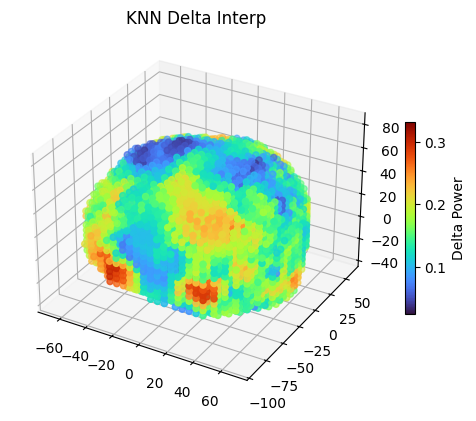

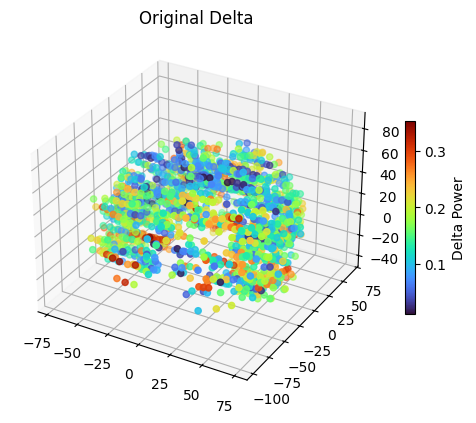

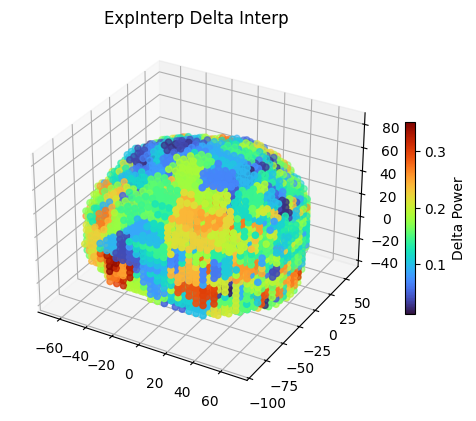

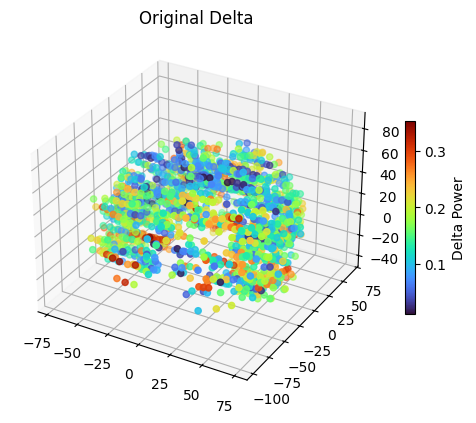

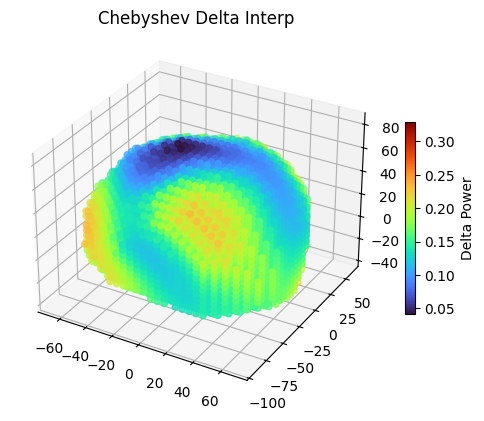

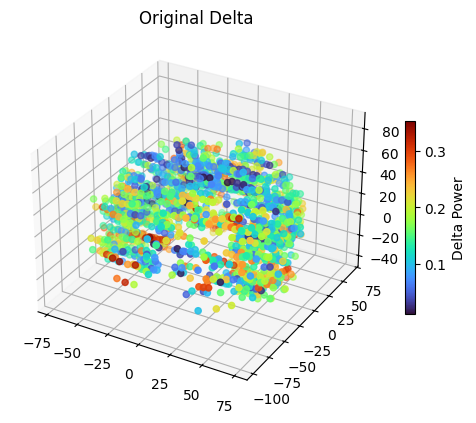

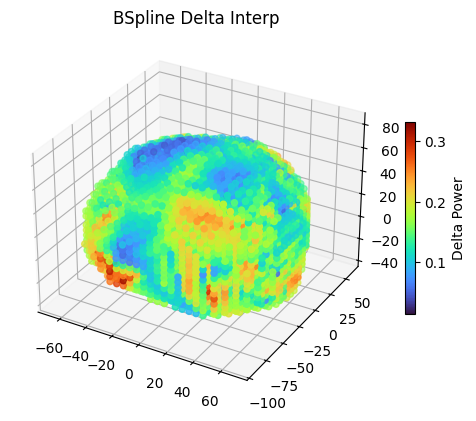

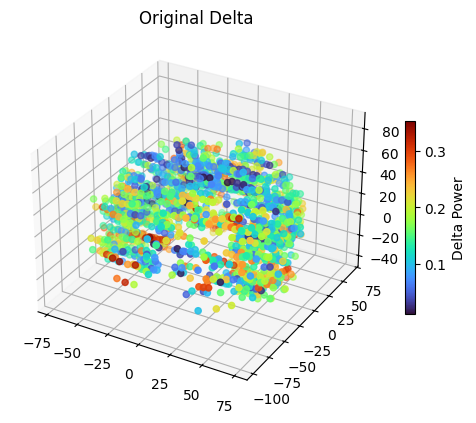

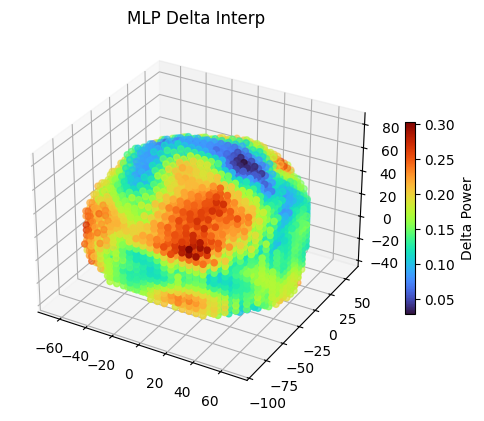

In [10]:
import os
import time
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.spatial import ConvexHull, Delaunay
from scipy.interpolate import griddata
from scipy.ndimage import map_coordinates
from scipy.stats import pearsonr
from pykrige.ok3d import OrdinaryKriging3D
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from numpy.polynomial.chebyshev import chebvander
from sklearn.linear_model import Ridge
import torch
import torch.nn as nn
import torch.optim as optim
import copy

# ============================================
# 1. Data Loading (Delta Band Only)
# ============================================
coords = np.load(os.path.join(seeg_path, 'coords.npy'))        # shape: (N,3)
band_powers = np.load(os.path.join(seeg_path, 'band_powers.npy'),
                      allow_pickle=True).item()
values = np.array(band_powers['Delta'], dtype=float)           # shape: (N,)

# ============================================
# 2. Domain Hull & Global Grid (for B-spline)
# ============================================
hull     = ConvexHull(coords)
delaunay = Delaunay(coords[hull.vertices])
res = 30
xi = np.linspace(coords[:,0].min(), coords[:,0].max(), res)
yi = np.linspace(coords[:,1].min(), coords[:,1].max(), res)
zi = np.linspace(coords[:,2].min(), coords[:,2].max(), res)
Xi, Yi, Zi = np.meshgrid(xi, yi, zi, indexing='ij')
grid_pts = np.vstack([Xi.ravel(), Yi.ravel(), Zi.ravel()]).T
inside = delaunay.find_simplex(grid_pts) >= 0
grid_pts = grid_pts[inside]

# Precompute global Vgrid and patch NaNs for B-spline
Vgrid = griddata(coords, values, (Xi, Yi, Zi), method='linear')
nanmask = np.isnan(Vgrid)
if nanmask.any():
    Vgrid[nanmask] = griddata(
        coords, values,
        (Xi[nanmask], Yi[nanmask], Zi[nanmask]),
        method='nearest'
    )

# ============================================
# 3. Define Residual MLP Model & Device
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ResidualMLP(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim, layers=5, drop=0.3):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.BatchNorm1d(hid_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(drop)
        )
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hid_dim, hid_dim),
                nn.BatchNorm1d(hid_dim),
                nn.LeakyReLU(0.1),
                nn.Dropout(drop)
            ) for _ in range(layers)
        ])
        self.out = nn.Linear(hid_dim, out_dim)

    def forward(self, x):
        x = self.inp(x)
        for block in self.blocks:
            res = x
            x = block(x) + res
        return self.out(x)

# ============================================
# 4. Interpolation Functions
# ============================================
def interp_kriging(train_c, train_v, pts, model='exponential'):
    OK = OrdinaryKriging3D(*train_c.T, train_v,
                           variogram_model=model,
                           verbose=False,
                           enable_plotting=False)
    return OK.execute('points', *(pts.T))[0]

def interp_linear(train_c, train_v, pts):
    lin = griddata(train_c, train_v, pts, method='linear')
    nanm = np.isnan(lin)
    if nanm.any():
        lin[nanm] = griddata(train_c, train_v, pts[nanm], method='nearest')
    return lin

def interp_knn(train_c, train_v, pts, k=5):
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(train_c, train_v)
    return knn.predict(pts)

def interp_exp_kernel(train_c, train_v, pts, alpha=5.0):
    dists = np.linalg.norm(train_c[None,:,:] - pts[:,None,:], axis=2)
    w = np.exp(-alpha * dists)
    return (w * train_v[None,:]).sum(axis=1) / w.sum(axis=1)

def interp_chebyshev(train_c, train_v, pts, degree=3, alpha=1.0):
    mins, maxs = train_c.min(axis=0), train_c.max(axis=0)
    S = 2 * (train_c - mins) / (maxs - mins) - 1
    feats = [chebvander(S[:,i], degree) for i in range(3)]
    combo = np.einsum('ij,ik,il->ijkl', *feats).reshape(train_c.shape[0], -1)
    Snew = 2 * (pts - mins) / (maxs - mins) - 1
    feats_new = [chebvander(Snew[:,i], degree) for i in range(3)]
    combo_new = np.einsum('ij,ik,il->ijkl', *feats_new).reshape(pts.shape[0], -1)
    mdl = Ridge(alpha=alpha)
    mdl.fit(combo, train_v)
    return mdl.predict(combo_new)

def interp_bspline(train_c, train_v, pts, order=3):
    idx = (pts[:,0] - xi.min()) / (xi.max() - xi.min()) * (res-1)
    idy = (pts[:,1] - yi.min()) / (yi.max() - yi.min()) * (res-1)
    idz = (pts[:,2] - zi.min()) / (zi.max() - zi.min()) * (res-1)
    coords_idx = np.vstack([idx, idy, idz])
    return map_coordinates(Vgrid, coords_idx, order=order, mode='nearest')

def interp_mlp(model, scaler, poly, pts):
    Xp = poly.transform(pts)
    Xs = scaler.transform(Xp)
    inp = torch.from_numpy(Xs).float().to(device)
    model.eval()
    with torch.no_grad():
        out = model(inp)
    return out.cpu().numpy().squeeze()

# ============================================
# 5. Set Up Methods Dictionary
# ============================================
methods = {
    'ExpKrig':   lambda tc,tv,pts: interp_kriging(tc, tv, pts, 'exponential'),
    'Linear':    interp_linear,
    'KNN':       interp_knn,
    'ExpInterp': lambda tc,tv,pts: interp_exp_kernel(tc, tv, pts, alpha=5.0),
    'Chebyshev': interp_chebyshev,
    'BSpline':   interp_bspline,
    'MLP':       None  # assigned after MLP training
}

# ============================================
# 6. Prepare & Train MLP on Full Delta Dataset
# ============================================
poly_feat   = PolynomialFeatures(degree=2, include_bias=False)
coords_poly = poly_feat.fit_transform(coords)
scaler      = StandardScaler().fit(coords_poly)
X_all       = torch.from_numpy(scaler.transform(coords_poly)).float()
y_all       = torch.from_numpy(values).float().unsqueeze(-1)

mlp = ResidualMLP(X_all.shape[1], 128, 1).to(device)
optimizer = optim.Adam(mlp.parameters(), lr=1e-4, weight_decay=1e-5)
loss_fn   = nn.SmoothL1Loss()

best_loss = float('inf')
epochs_no_improve = 0
for epoch in range(800):
    mlp.train()
    optimizer.zero_grad()
    preds = mlp(X_all.to(device))
    loss  = loss_fn(preds, y_all.to(device))
    loss.backward()
    optimizer.step()
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_wts = copy.deepcopy(mlp.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= 50:
        break

mlp.load_state_dict(best_wts)
methods['MLP'] = lambda tc, tv, pts: interp_mlp(mlp, scaler, poly_feat, pts)

# ============================================
# 7. Cross-Validation & Timing
# ============================================
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = ['MSE','MAE','RMSE','R2','R']
results = {m:{met:[] for met in metrics} for m in methods}
times   = {m:[] for m in methods}

def calc_metrics(true, pred):
    mask = ~np.isnan(pred)
    if mask.sum() == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    mse  = mean_squared_error(true[mask], pred[mask])
    mae  = mean_absolute_error(true[mask], pred[mask])
    rmse = sqrt(mse)
    r2   = r2_score(true[mask], pred[mask])
    r    = pearsonr(true[mask], pred[mask])[0]
    return mse, mae, rmse, r2, r

for m, fn in methods.items():
    for tr, te in kf.split(coords):
        tc, tv = coords[tr], values[tr]
        vc, vv = coords[te], values[te]
        t0 = time.time()
        preds = fn(tc, tv, vc)
        dt = time.time() - t0
        mse, mae, rmse, r2, r = calc_metrics(vv, preds)
        for met,val in zip(metrics, [mse, mae, rmse, r2, r]):
            results[m][met].append(val)
        times[m].append(dt)

# Final interpolation timing
final_times = {}
for m, fn in methods.items():
    t0 = time.time()
    _  = fn(coords, values, grid_pts)
    final_times[m] = time.time() - t0

# ============================================
# 8. Summary Tables
# ============================================
# Metrics
rows = []
for m in methods:
    rows.append({'Method': m,
                 **{met: np.nanmean(results[m][met]) for met in metrics}})
df_metrics = pd.DataFrame(rows)
print('# Delta Band CV Metrics')
print(df_metrics.to_string(index=False))

# Timing
trows = []
for m in methods:
    trows.append({
        'Method':    m,
        'CV_Avg(s)':  np.nanmean(times[m]),
        'CV_Tot(s)':  np.nansum(times[m]),
        'Final(s)':   final_times[m]
    })
df_time = pd.DataFrame(trows)
print('\n# Delta Band Timing')
print(df_time.to_string(index=False))

# ============================================
# 9. Scatter Plot: Average Metrics for Methods
# ============================================
methods_list = list(methods.keys())
df_plot = pd.DataFrame({
    'Method': methods_list,
    'MSE':    [np.nanmean(results[m]['MSE'])  for m in methods_list],
    'MAE':    [np.nanmean(results[m]['MAE'])  for m in methods_list],
    'RMSE':   [np.nanmean(results[m]['RMSE']) for m in methods_list],
    'R2':     [np.nanmean(results[m]['R2'])   for m in methods_list],
    'R':      [np.nanmean(results[m]['R'])    for m in methods_list],
})
metrics_list = ['MSE','MAE','RMSE','R2','R']
num_m = len(df_plot)
x_positions = np.arange(num_m)
offsets = np.linspace(-0.2, 0.2, len(metrics_list))

plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics_list):
    y = df_plot[metric].values
    x_off = x_positions + offsets[i]
    plt.scatter(x_off, y, label=metric, s=80)
for i in range(num_m-1):
    plt.axvline((x_positions[i]+x_positions[i+1])/2, color='black', linestyle='--', linewidth=1)
plt.xticks(x_positions, df_plot['Method'], rotation=45, fontsize=10)
plt.xlabel('Method')
plt.ylabel('Metric Value')
plt.title('Average CV Metrics for All Methods')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 10. 3D Visualizations (turbo colormap, no hull lines)
# ============================================
for m, fn in methods.items():
    # original
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(*coords.T, c=values, cmap='turbo', s=20)
    fig.colorbar(sc, ax=ax, shrink=0.5, label='Delta Power')
    ax.set_title('Original Delta')
    plt.show()

    # interpolated
    iv = fn(coords, values, grid_pts)
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    sc2 = ax.scatter(*grid_pts.T, c=iv, cmap='turbo', s=20)
    fig.colorbar(sc2, ax=ax, shrink=0.5, label='Delta Power')
    ax.set_title(f'{m} Delta Interp')
    plt.show()
